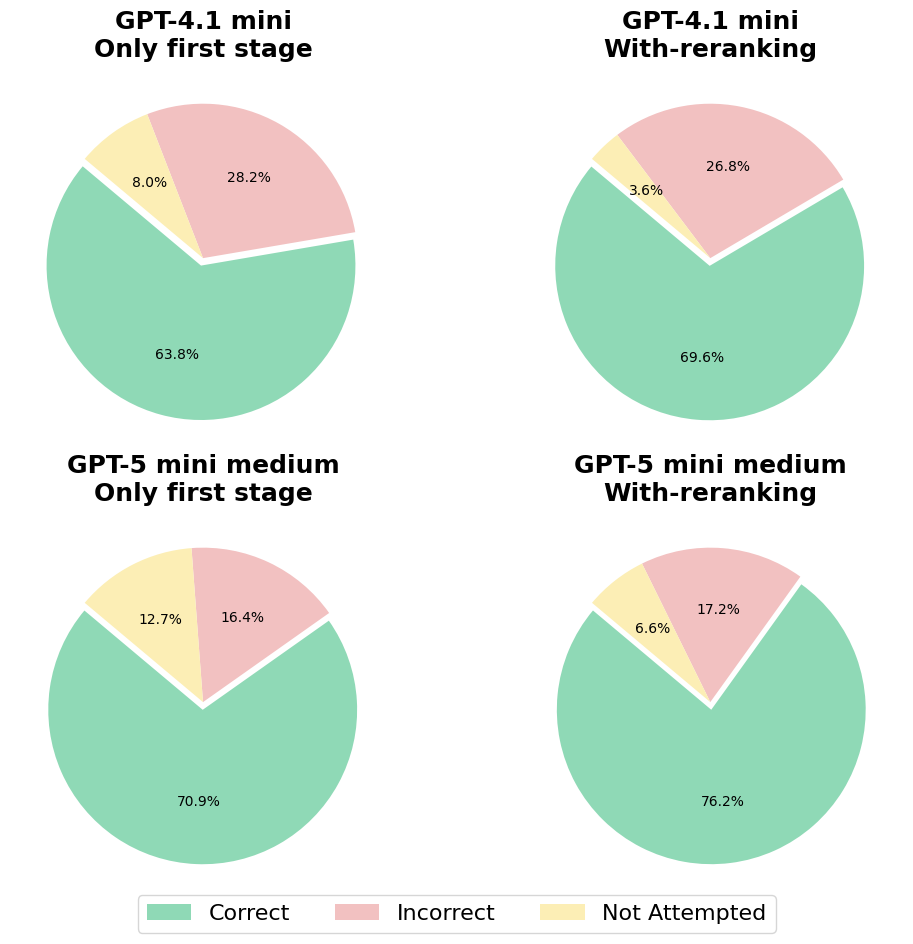

In [7]:
import matplotlib.pyplot as plt

def draw_pie_charts(data_dict):
    """
    Draws a 2x2 grid of pie charts based on model performance data.
    
    Args:
        data_dict (dict): Nested dictionary with model names and stage results.
    """
    labels = ['Correct', 'Incorrect', 'Not Attempted']
    # Colors matching the spreadsheet: Light Green, Light Pink, Light Yellow
    colors = ['#8fd9b6', '#f2c1c1', '#fceeb5'] 
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    chart_idx = 0
    for model, stages in data_dict.items():
        for stage_name, values in stages.items():
            ax = axes[chart_idx]
            # Draw the pie chart
            ax.pie(
                values, 
                labels=None, 
                autopct='%1.1f%%', 
                startangle=140, 
                colors=colors,
                explode=(0.05, 0, 0) # Highlight the 'Correct' segment
            )
            ax.set_title(f"{model}\n{stage_name}", fontsize=18, fontweight='bold')
            chart_idx += 1
            
    # Add a single legend for all charts
    fig.legend(labels, loc='lower center', ncol=3, fontsize=16)
    plt.subplots_adjust(bottom=0.05, hspace=0.15)
    plt.savefig('EffectOfRerank.pdf')
    plt.show()

# Data extracted from the image
performance_data = {
    'GPT-4.1 mini': {
        'Only first stage': [63.8, 28.2, 8.0],
        'With-reranking': [69.6, 26.8, 3.6]
    },
    'GPT-5 mini medium': {
        'Only first stage': [70.9, 16.4, 12.7],
        'With-reranking': [76.2, 17.2, 6.6]
    }
}

draw_pie_charts(performance_data)